# Welly AI Project Progress Notebook

โครงงานนี้มุ่งพัฒนาระบบช่วยวิเคราะห์โภชนาการอาหารและให้คำแนะนำเบื้องต้นผ่าน chatbot
โดยใช้ข้อมูลอาหารเชิงโครงสร้างร่วมกับความรู้จากเอกสารมาตรฐานด้านโภชนาการ

## 1. Review Scope Project

### Problem Statement
โครงงานนี้มีเป้าหมายเพื่อวิเคราะห์ข้อมูลโภชนาการของอาหาร และประเมินระดับความเสี่ยงเบื้องต้นของอาหารแต่ละรายการ
โดยอาศัยข้อมูลโภชนาการ เช่น calories, fat, saturated fat, sugar, cholesterol และ sodium

### Initial Scope
เดิมโครงงานมีแนวคิดกว้าง ครอบคลุมทั้ง nutrition analysis, recommendation และ chatbot

### Comments Received
- ควรลด scope ให้ชัดขึ้น
- ควรเลือก structured dataset หลักให้ชัดเจน
- ควรมี EDA, Data Preparation และ Modelling ที่เห็นขั้นตอนชัด
- หากใช้ PDF ควรแปลงให้เป็น structured knowledge ก่อน

### Scope Adjustment
หลังจากได้รับ comment ได้ปรับขอบเขตโครงงานดังนี้
1. ใช้ food/nutrition dataset เป็น structured dataset หลัก
2. ใช้ข้อมูลจาก PDF เป็น external knowledge/reference
3. แปลงข้อมูลจาก PDF ให้อยู่ในรูป structured tables
4. ใช้เกณฑ์จาก PDF เพื่อช่วยสร้าง logic/rules สำหรับประเมินอาหาร
5. ทดลองสร้าง baseline model สำหรับจัดระดับความเสี่ยงของอาหาร

## 2. Data Sources

### Structured Dataset
- FOOD-DATA-GROUP1.csv ถึง FOOD-DATA-GROUP5.csv
- Food Nutri.csv
- Food Nutri 2.csv
- calories.csv

### External Knowledge
- media.pdf
- DGA.pdf

### Objective of This Notebook
Notebook นี้ใช้สำหรับ
1. รวมและสำรวจข้อมูลอาหาร
2. ตรวจสอบคุณภาพข้อมูล
3. เตรียมข้อมูลสำหรับการสร้างโมเดล
4. ทดลอง baseline classification model

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Load Dataset

ในส่วนนี้เลือกใช้ FOOD-DATA-GROUP1 ถึง FOOD-DATA-GROUP5 เป็น dataset หลัก
และรวมข้อมูลทั้งหมดเข้าด้วยกันเพื่อใช้ในการวิเคราะห์

In [2]:
group_files = [
    '../data/FOOD-DATA-GROUP1.csv',
    '../data/FOOD-DATA-GROUP2.csv',
    '../data/FOOD-DATA-GROUP3.csv',
    '../data/FOOD-DATA-GROUP4.csv',
    '../data/FOOD-DATA-GROUP5.csv',
]

for f in group_files:
    print(f, '->', os.path.exists(f))

../data/FOOD-DATA-GROUP1.csv -> True
../data/FOOD-DATA-GROUP2.csv -> True
../data/FOOD-DATA-GROUP3.csv -> True
../data/FOOD-DATA-GROUP4.csv -> True
../data/FOOD-DATA-GROUP5.csv -> True


In [3]:
df_list = [pd.read_csv(f) for f in group_files]
df = pd.concat(df_list, ignore_index=True)

print('Combined shape:', df.shape)
df.head()

Combined shape: (2395, 37)


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,Cholesterol,Sodium,Water,Vitamin A,Vitamin B1,Vitamin B11,Vitamin B12,Vitamin B2,Vitamin B3,Vitamin B5,Vitamin B6,Vitamin C,Vitamin D,Vitamin E,Vitamin K,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,0.9,0.0,14.6,0.016,7.6,0.200,0.033,0.064,0.092,0.097,0.084,0.052,0.096,0.004,0.000,0.000,0.100,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,1,1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,7.8,0.0,62.9,0.300,53.6,0.200,0.099,0.079,0.090,0.100,0.200,0.500,0.078,0.000,0.000,0.300,0.045,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,2,2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,0.8,0.1,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,3,3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,1.5,0.0,9.8,0.017,14.7,0.075,0.019,0.079,0.091,0.027,0.041,0.016,0.007,0.006,0.000,0.001,0.011,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,4,4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,1.2,0.0,8.1,0.046,10.0,0.016,0.080,0.062,0.049,0.026,0.080,0.100,0.003,0.000,0.036,0.009,0.019,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


In [4]:
print(df.columns.tolist())

['Unnamed: 0.1', 'Unnamed: 0', 'food', 'Caloric Value', 'Fat', 'Saturated Fats', 'Monounsaturated Fats', 'Polyunsaturated Fats', 'Carbohydrates', 'Sugars', 'Protein', 'Dietary Fiber', 'Cholesterol', 'Sodium', 'Water', 'Vitamin A', 'Vitamin B1', 'Vitamin B11', 'Vitamin B12', 'Vitamin B2', 'Vitamin B3', 'Vitamin B5', 'Vitamin B6', 'Vitamin C', 'Vitamin D', 'Vitamin E', 'Vitamin K', 'Calcium', 'Copper', 'Iron', 'Magnesium', 'Manganese', 'Phosphorus', 'Potassium', 'Selenium', 'Zinc', 'Nutrition Density']


## 4. Exploratory Data Analysis (EDA)

เริ่มจากการสำรวจโครงสร้างข้อมูล ได้แก่ จำนวนแถว จำนวนคอลัมน์ ชนิดข้อมูล
และการตรวจสอบ missing values ก่อนวิเคราะห์เชิงลึก

In [5]:
print('Shape:', df.shape)

Shape: (2395, 37)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          2395 non-null   int64  
 1   Unnamed: 0            2395 non-null   int64  
 2   food                  2395 non-null   str    
 3   Caloric Value         2395 non-null   int64  
 4   Fat                   2395 non-null   float64
 5   Saturated Fats        2395 non-null   float64
 6   Monounsaturated Fats  2395 non-null   float64
 7   Polyunsaturated Fats  2395 non-null   float64
 8   Carbohydrates         2395 non-null   float64
 9   Sugars                2395 non-null   float64
 10  Protein               2395 non-null   float64
 11  Dietary Fiber         2395 non-null   float64
 12  Cholesterol           2395 non-null   float64
 13  Sodium                2395 non-null   float64
 14  Water                 2395 non-null   float64
 15  Vitamin A             2395 non-n

In [7]:
df.isnull().sum().sort_values(ascending=False)

Unnamed: 0.1            0
Vitamin B2              0
Vitamin B5              0
Vitamin B6              0
Vitamin C               0
Vitamin D               0
Vitamin E               0
Vitamin K               0
Calcium                 0
Copper                  0
Iron                    0
Magnesium               0
Manganese               0
Phosphorus              0
Potassium               0
Selenium                0
Zinc                    0
Vitamin B3              0
Vitamin B12             0
Unnamed: 0              0
Vitamin B11             0
food                    0
Caloric Value           0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Protein                 0
Dietary Fiber           0
Cholesterol             0
Sodium                  0
Water                   0
Vitamin A               0
Vitamin B1              0
Nutrition Density       0
dtype: int64

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,2395.0,NaN,NaN,NaN,272.258038,182.889214,0.0,119.0,241.0,414.5,721.0
Unnamed: 0,2395.0,NaN,NaN,NaN,272.258038,182.889214,0.0,119.0,241.0,414.5,721.0
food,2395,2395,cream cheese,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Caloric Value,2395.0,NaN,NaN,NaN,223.76952,384.728244,0.0,44.5,117.0,258.0,6077.0
Fat,2395.0,NaN,NaN,NaN,10.176276,29.008915,0.0,0.3,2.1,9.4,550.7
Saturated Fats,2395.0,NaN,NaN,NaN,3.924917,19.502262,0.0,0.064,0.5,2.7,672.0
Monounsaturated Fats,2395.0,NaN,NaN,NaN,4.133622,12.939587,0.0,0.058,0.5,3.4,291.1
Polyunsaturated Fats,2395.0,NaN,NaN,NaN,2.152844,7.145738,0.0,0.071,0.4,1.7,188.0
Carbohydrates,2395.0,NaN,NaN,NaN,18.589021,29.406134,0.0,0.5,6.8,25.05,390.2
Sugars,2395.0,NaN,NaN,NaN,4.457459,13.339929,0.0,0.0,0.086,3.2,291.5


### EDA Observation
จากการสำรวจเบื้องต้น พบว่าข้อมูลมีหลายคอลัมน์ด้านโภชนาการ และบางคอลัมน์อาจมี missing values
ดังนั้นจำเป็นต้องเลือกเฉพาะตัวแปรที่สำคัญและแปลงข้อมูลให้อยู่ในรูป numeric ก่อนเข้าสู่ขั้น Data Preparation

In [9]:
df.columns = [c.strip() for c in df.columns]
df.columns.tolist()

['Unnamed: 0.1',
 'Unnamed: 0',
 'food',
 'Caloric Value',
 'Fat',
 'Saturated Fats',
 'Monounsaturated Fats',
 'Polyunsaturated Fats',
 'Carbohydrates',
 'Sugars',
 'Protein',
 'Dietary Fiber',
 'Cholesterol',
 'Sodium',
 'Water',
 'Vitamin A',
 'Vitamin B1',
 'Vitamin B11',
 'Vitamin B12',
 'Vitamin B2',
 'Vitamin B3',
 'Vitamin B5',
 'Vitamin B6',
 'Vitamin C',
 'Vitamin D',
 'Vitamin E',
 'Vitamin K',
 'Calcium',
 'Copper',
 'Iron',
 'Magnesium',
 'Manganese',
 'Phosphorus',
 'Potassium',
 'Selenium',
 'Zinc',
 'Nutrition Density']

In [10]:
column_map_candidates = {
    'food_name': ['Food', 'food', 'Food Name', 'food_name', 'item', 'Item', 'Dish'],
    'calories': ['Caloric Value', 'Calories', 'calories', 'Energy', 'energy', 'kcal'],
    'fat': ['Fat', 'Total Fat', 'fat'],
    'sat_fat': ['Saturated Fats', 'Saturated Fat', 'sat_fat'],
    'carbs': ['Carbohydrates', 'Total Carbohydrate', 'carbs', 'Carbohydrate'],
    'sugar': ['Sugars', 'Sugar', 'sugar'],
    'protein': ['Protein', 'protein'],
    'fiber': ['Dietary Fiber', 'Fiber', 'fiber'],
    'cholesterol': ['Cholesterol', 'cholesterol'],
    'sodium': ['Sodium', 'sodium']
}

resolved_columns = {}
for std_name, options in column_map_candidates.items():
    found = None
    for opt in options:
        if opt in df.columns:
            found = opt
            break
    resolved_columns[std_name] = found

resolved_columns

{'food_name': 'food',
 'calories': 'Caloric Value',
 'fat': 'Fat',
 'sat_fat': 'Saturated Fats',
 'carbs': 'Carbohydrates',
 'sugar': 'Sugars',
 'protein': 'Protein',
 'fiber': 'Dietary Fiber',
 'cholesterol': 'Cholesterol',
 'sodium': 'Sodium'}

In [11]:
selected_cols = [v for v in resolved_columns.values() if v is not None]
df_eda = df[selected_cols].copy()

rename_dict = {v: k for k, v in resolved_columns.items() if v is not None}
df_eda = df_eda.rename(columns=rename_dict)

df_eda.head()

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,0.0,14.6,0.016
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,0.0,62.9,0.300
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.1,0.0,0.000
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,0.0,9.8,0.017
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,0.0,8.1,0.046


In [12]:
nutrition_cols = ['calories', 'fat', 'sat_fat', 'carbs', 'sugar', 'protein', 'fiber', 'cholesterol', 'sodium']

for col in nutrition_cols:
    if col not in df_eda.columns:
        df_eda[col] = np.nan
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   food_name    2395 non-null   str    
 1   calories     2395 non-null   int64  
 2   fat          2395 non-null   float64
 3   sat_fat      2395 non-null   float64
 4   carbs        2395 non-null   float64
 5   sugar        2395 non-null   float64
 6   protein      2395 non-null   float64
 7   fiber        2395 non-null   float64
 8   cholesterol  2395 non-null   float64
 9   sodium       2395 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 187.2 KB


In [13]:
df_eda[nutrition_cols].isnull().sum()

calories       0
fat            0
sat_fat        0
carbs          0
sugar          0
protein        0
fiber          0
cholesterol    0
sodium         0
dtype: int64

In [14]:
df_eda[nutrition_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
calories,2395.0,223.769520,384.728244,0.0,44.500,117.000,258.00,6077.0
fat,2395.0,10.176276,29.008915,0.0,0.300,2.100,9.40,550.7
sat_fat,2395.0,3.924917,19.502262,0.0,0.064,0.500,2.70,672.0
carbs,2395.0,18.589021,29.406134,0.0,0.500,6.800,25.05,390.2
sugar,2395.0,4.457459,13.339929,0.0,0.000,0.086,3.20,291.5
protein,2395.0,13.400777,32.294246,0.0,0.800,3.500,13.30,560.3
fiber,2395.0,2.235790,5.404483,0.0,0.000,0.200,2.20,76.5
cholesterol,2395.0,62.171937,385.352876,0.0,0.000,0.000,26.45,10509.0
sodium,2395.0,0.293888,1.116117,0.0,0.036,0.086,0.30,49.4


### Distribution of Nutrition Features

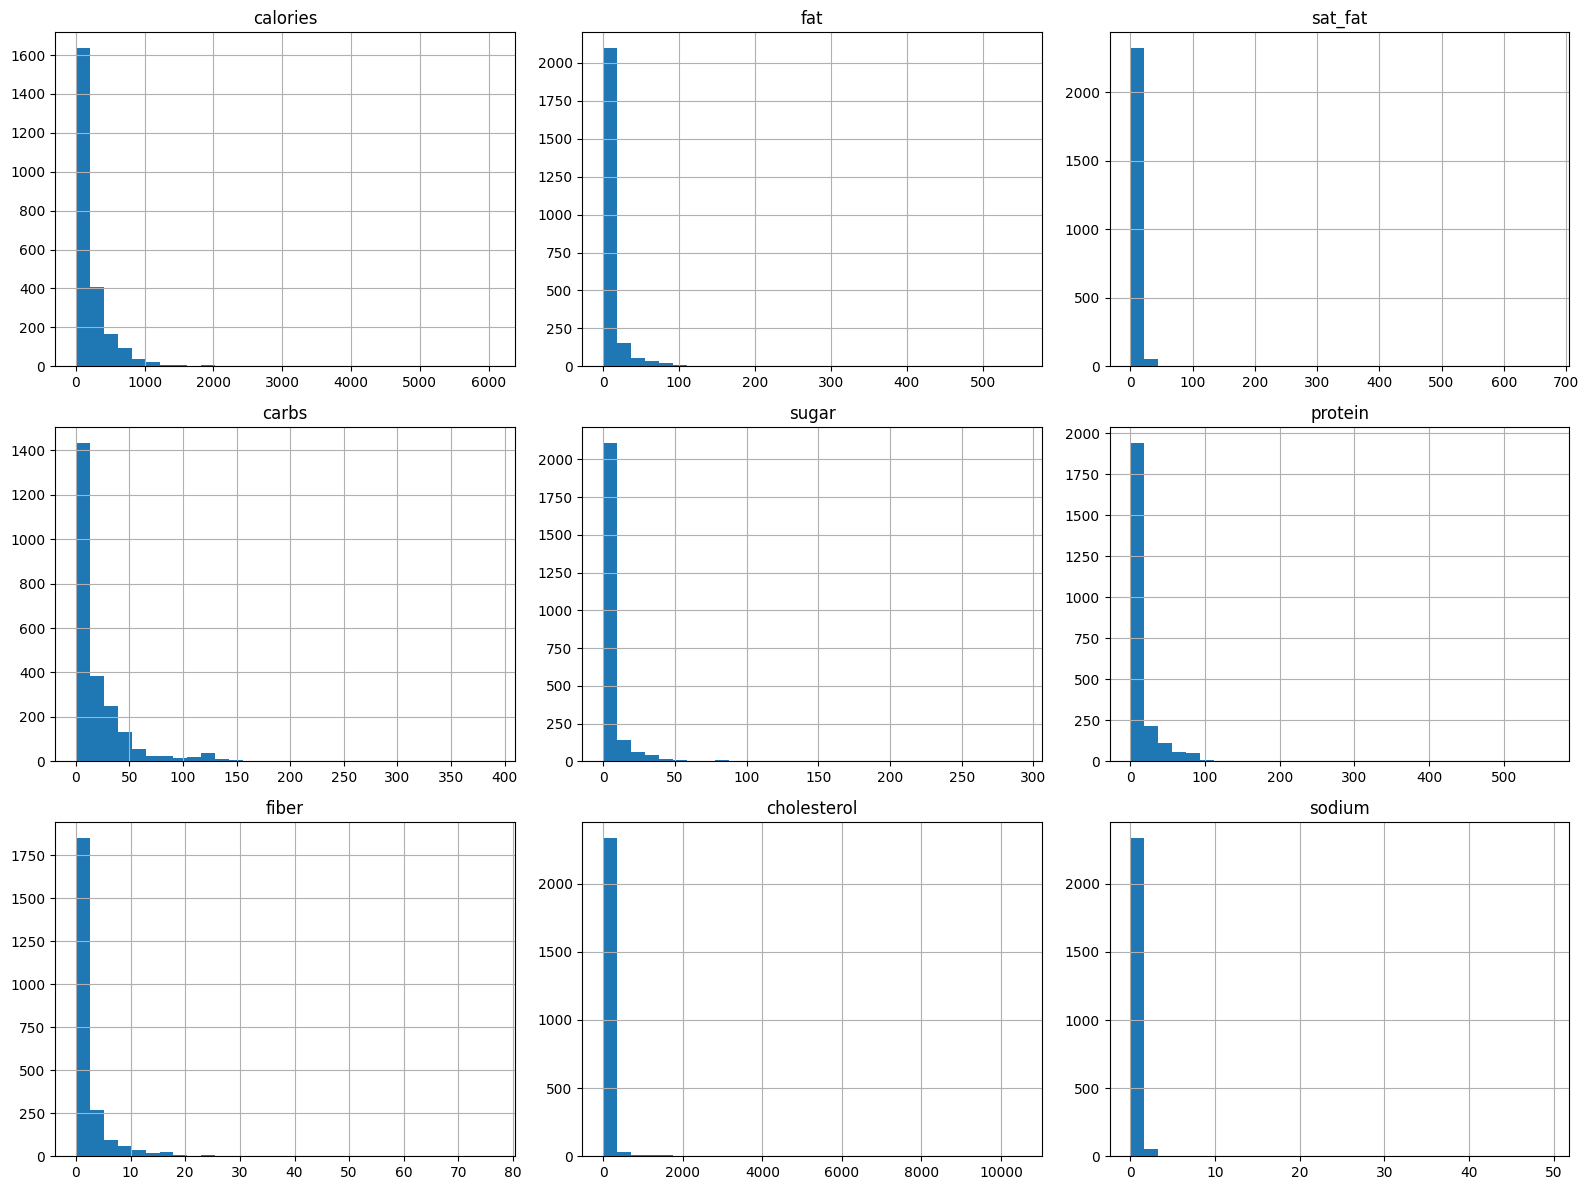

In [15]:
df_eda[nutrition_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

### Correlation Matrix

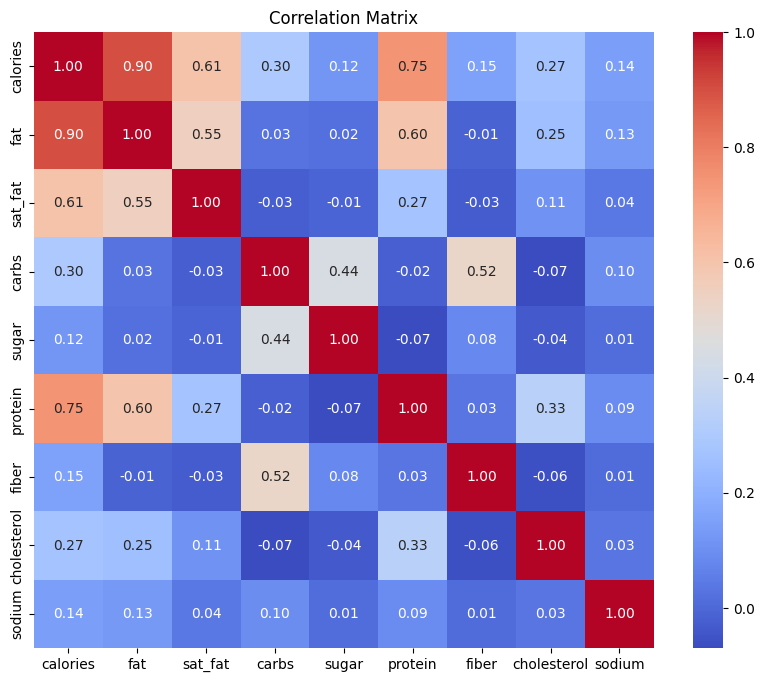

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda[nutrition_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Outlier Check

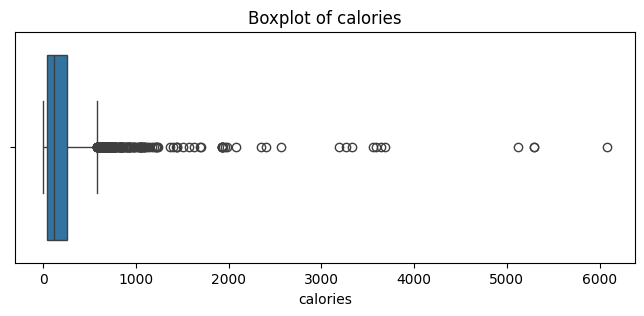

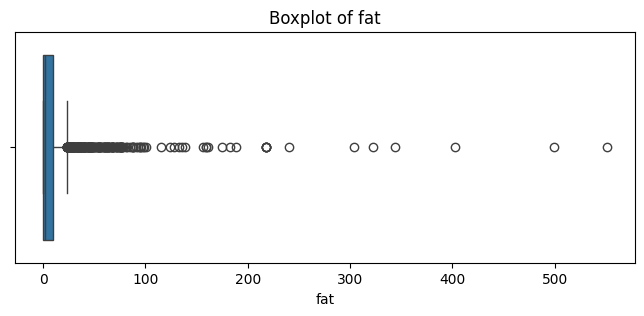

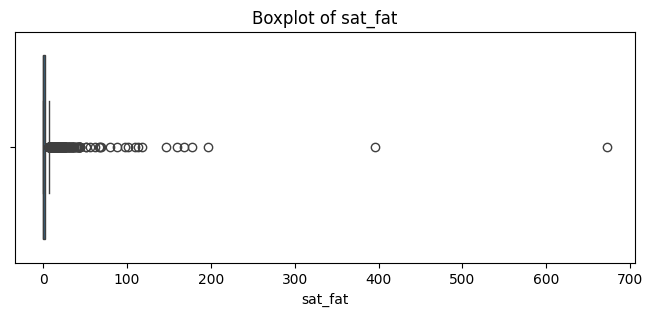

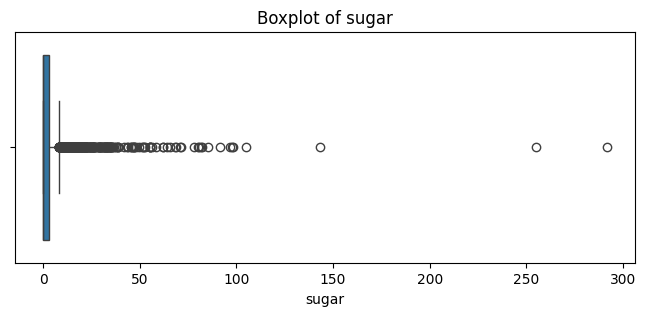

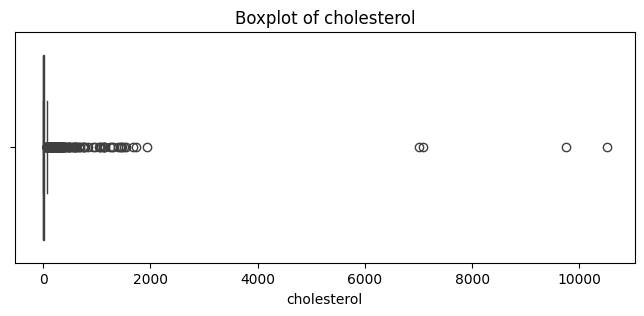

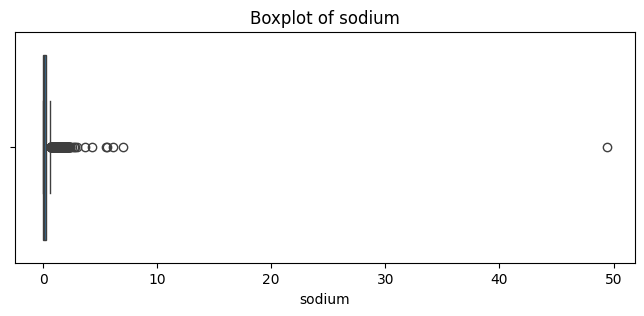

In [17]:
for col in ['calories', 'fat', 'sat_fat', 'sugar', 'cholesterol', 'sodium']:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_eda[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [18]:
df_eda.sort_values('sodium', ascending=False).head(10)

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium
1943,adobo fresco,780,60.2,8.4,53.600,5.8,5.8,3.7,0.0,49.4
1047,salt,0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,7.0
389,salt mackerel,415,34.1,9.7,0.000,0.0,25.2,0.0,129.2,6.1
370,jellyfish dried,21,0.8,0.2,0.000,0.0,3.2,0.0,2.9,5.6
1219,corned beef raw,898,67.6,21.5,0.600,0.0,66.6,0.0,244.9,5.5
1393,pork feet pickled,635,45.5,13.4,0.029,0.0,52.8,0.0,376.5,4.3
1382,pork blade roll roasted,1079,88.3,31.5,1.400,0.0,65.0,0.0,251.9,3.7
854,white rice pasta raw,600,4.0,0.7,122.800,0.0,15.3,0.0,3.3,3.0
707,banana cream pie,3190,161.3,44.6,390.200,143.0,52.2,8.3,604.9,2.8
848,rice pilaf raw,732,2.8,0.0,155.700,3.1,21.3,2.4,0.0,2.7


In [19]:
df_eda.sort_values('cholesterol', ascending=False).head(10)

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium
1294,veal brain cooked,461,32.6,7.4,0.0,0.0,38.9,0.0,10509.0,0.5
1320,pork brain cooked,527,36.3,8.2,0.0,0.0,46.4,0.0,9748.6,0.3
1323,lamb brain cooked,503,35.3,9.0,0.0,0.0,43.5,0.0,7089.2,0.5
1299,beef brain cooked,688,55.6,13.1,0.0,0.0,44.1,0.0,7002.5,0.6
1376,pork arm picnic cooked,5292,322.7,109.3,0.0,0.0,560.3,0.0,1936.7,2.2
1374,pork arm picnic raw,5298,343.4,113.6,0.0,0.0,513.6,0.0,1729.4,2.3
1314,lamb liver cooked,739,29.6,11.5,8.5,0.0,102.7,0.0,1683.4,0.2
1313,veal spleen cooked,445,10.0,3.3,0.0,0.0,83.1,0.0,1542.2,0.2
1358,pork splean cooked,446,9.6,3.2,0.0,0.0,84.3,0.0,1507.0,0.3
1406,turkey breast raw,3554,158.9,43.2,0.0,0.0,495.6,0.0,1471.6,1.3


## EDA Summary

จากการวิเคราะห์เบื้องต้น พบว่า
- ตัวแปรโภชนาการหลายตัวมีการกระจายแบบเบ้ขวา
- มี outlier ชัดเจนใน sodium, cholesterol, sugar และ saturated fat
- sodium, saturated fat, sugar และ cholesterol เป็นตัวแปรสำคัญที่เหมาะสำหรับใช้ประเมินความเสี่ยงของอาหาร
- ข้อมูลบางส่วนยังมี missing values และต้องจัดการในขั้น Data Preparation

## 5. Load Structured Knowledge from PDF

ในส่วนนี้ใช้ความรู้ที่แปลงจาก PDF ให้อยู่ในรูป structured tables
เพื่อใช้เป็นเกณฑ์อ้างอิงในการประเมินอาหาร

In [20]:
standard_df = pd.read_csv('../data/knowledge/standard_df.csv')
claim_rules_df = pd.read_csv('../data/knowledge/claim_rules_df.csv')
dga_standard_df = pd.read_csv('../data/knowledge/dga_standard_df.csv')
dga_rules_df = pd.read_csv('../data/knowledge/dga_rules_df.csv')

standard_df

,source_doc,category,metric,recommended_value,unit,note
0,media.pdf,daily_reference,Energy,2000,kcal/day,Thai RDI reference base
1,media.pdf,daily_reference,Total Fat,65,g/day,Thai RDI reference
2,media.pdf,daily_reference,Saturated Fat,20,g/day,Thai RDI reference
3,media.pdf,daily_reference,Cholesterol,300,mg/day,Thai RDI reference
4,media.pdf,daily_reference,Total Carbohydrate,300,g/day,Thai RDI reference
5,media.pdf,daily_reference,Dietary Fiber,25,g/day,Thai RDI reference
6,media.pdf,daily_reference,Sodium,2000,mg/day,legacy value in source document


In [21]:
claim_rules_df

,source_doc,rule_name,condition_type,nutrient,value,unit
0,media.pdf,healthy_claim,max,Sodium,360,mg_per_serving_reference
1,media.pdf,healthy_claim,max,Cholesterol,60,mg_per_serving_reference
2,media.pdf,healthy_claim,min_percent_rdi,Protein/Fiber/Vitamin/Calcium/Iron,10,%Thai_RDI


ข้อมูลจาก PDF ถูกนำมาใช้เป็น external nutrition knowledge เช่น
- ค่าอ้างอิงรายวันของ sodium, cholesterol, saturated fat และ dietary fiber
- กฎเกี่ยวกับ healthy claim
- ข้อแนะนำจาก DGA เช่น sugar limit และ sodium limit

## 6. Data Preparation

ในขั้นตอนนี้จะทำ
- เลือกตัวแปรที่ใช้ในการสร้างโมเดล
- ลบข้อมูลซ้ำ
- จัดการ missing values
- สร้าง feature ใหม่จากเกณฑ์มาตรฐาน
- สร้าง target label สำหรับโมเดล

In [22]:
df_model = df_eda.copy()
before_rows = df_model.shape[0]

df_model = df_model.drop_duplicates()
after_rows = df_model.shape[0]

print('Rows before:', before_rows)
print('Rows after removing duplicates:', after_rows)

Rows before: 2395
Rows after removing duplicates: 2395


In [23]:
for col in nutrition_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_model.isnull().sum()

food_name      0
calories       0
fat            0
sat_fat        0
carbs          0
sugar          0
protein        0
fiber          0
cholesterol    0
sodium         0
dtype: int64

In [24]:
THAI_RDI_SODIUM = 2000
THAI_RDI_CHOLESTEROL = 300
THAI_RDI_SAT_FAT = 20
THAI_RDI_FAT = 65
THAI_RDI_CARBS = 300
THAI_RDI_FIBER = 25
DGA_ADDED_SUGAR_LIMIT_PER_MEAL = 10

In [25]:
df_model['sodium_pct_daily'] = (df_model['sodium'] / THAI_RDI_SODIUM) * 100
df_model['cholesterol_pct_daily'] = (df_model['cholesterol'] / THAI_RDI_CHOLESTEROL) * 100
df_model['sat_fat_pct_daily'] = (df_model['sat_fat'] / THAI_RDI_SAT_FAT) * 100
df_model['fat_pct_daily'] = (df_model['fat'] / THAI_RDI_FAT) * 100
df_model['carbs_pct_daily'] = (df_model['carbs'] / THAI_RDI_CARBS) * 100
df_model['fiber_pct_daily'] = (df_model['fiber'] / THAI_RDI_FIBER) * 100
df_model['sugar_pct_meal_limit'] = (df_model['sugar'] / DGA_ADDED_SUGAR_LIMIT_PER_MEAL) * 100

df_model.head()

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium,sodium_pct_daily,cholesterol_pct_daily,sat_fat_pct_daily,fat_pct_daily,carbs_pct_daily,fiber_pct_daily,sugar_pct_meal_limit
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,0.0,14.6,0.016,0.00080,4.866667,14.5,7.692308,0.266667,0.0,5.00
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,0.0,62.9,0.300,0.01500,20.966667,54.5,29.846154,1.033333,0.0,27.00
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.1,0.0,0.000,0.00000,0.000000,11.5,5.538462,0.300000,0.4,34.00
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,0.0,9.8,0.017,0.00085,3.266667,6.5,3.076923,0.500000,0.0,0.91
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,0.0,8.1,0.046,0.00230,2.700000,7.0,3.538462,0.400000,0.0,9.00


Feature ใหม่เหล่านี้ช่วยให้สามารถตีความข้อมูลอาหารในเชิงมาตรฐานสุขภาพได้ง่ายขึ้น
เช่น sodium_pct_daily แสดงว่าอาหารหนึ่งรายการคิดเป็นกี่เปอร์เซ็นต์ของ sodium ต่อวันที่แนะนำ

In [26]:
def create_risk_label(row):
    score = 0

    if row['sodium'] >= 0.40 * THAI_RDI_SODIUM:
        score += 1
    if row['sat_fat'] >= 0.30 * THAI_RDI_SAT_FAT:
        score += 1
    if row['cholesterol'] >= 0.30 * THAI_RDI_CHOLESTEROL:
        score += 1
    if row['sugar'] >= DGA_ADDED_SUGAR_LIMIT_PER_MEAL:
        score += 1

    if score >= 3:
        return 'High'
    elif score >= 1:
        return 'Medium'
    return 'Low'

In [27]:
df_model['risk_level'] = df_model.apply(create_risk_label, axis=1)
df_model['risk_level'].value_counts()

risk_level
Low       1674
Medium     707
High        14
Name: count, dtype: int64

In [28]:
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_model['risk_label'] = df_model['risk_level'].map(label_map)

df_model.head()

,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium,sodium_pct_daily,cholesterol_pct_daily,sat_fat_pct_daily,fat_pct_daily,carbs_pct_daily,fiber_pct_daily,sugar_pct_meal_limit,risk_level,risk_label
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,0.0,14.6,0.016,0.00080,4.866667,14.5,7.692308,0.266667,0.0,5.00,Low,0
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,0.0,62.9,0.300,0.01500,20.966667,54.5,29.846154,1.033333,0.0,27.00,Medium,1
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.1,0.0,0.000,0.00000,0.000000,11.5,5.538462,0.300000,0.4,34.00,Low,0
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,0.0,9.8,0.017,0.00085,3.266667,6.5,3.076923,0.500000,0.0,0.91,Low,0
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,0.0,8.1,0.046,0.00230,2.700000,7.0,3.538462,0.400000,0.0,9.00,Low,0


ในขั้นนี้ได้สร้าง target variable คือ risk_level โดยอาศัยกฎจากเกณฑ์โภชนาการ
เพื่อใช้เป็น baseline target สำหรับการทดลองสร้าง classification model

In [29]:
feature_cols = [
    'calories',
    'fat',
    'sat_fat',
    'carbs',
    'sugar',
    'protein',
    'fiber',
    'cholesterol',
    'sodium',
    'sodium_pct_daily',
    'cholesterol_pct_daily',
    'sat_fat_pct_daily',
    'fat_pct_daily',
    'carbs_pct_daily',
    'fiber_pct_daily',
    'sugar_pct_meal_limit'
]

X = df_model[feature_cols]
y = df_model['risk_label']

X.shape, y.shape

((2395, 16), (2395,))

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train:', X_train.shape, y_train.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (1916, 16) (1916,)
Test: (479, 16) (479,)


## 7. Modelling

ในขั้นตอนนี้ทดลอง baseline models 3 แบบ ได้แก่
- Logistic Regression
- Decision Tree
- Random Forest

In [31]:
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=5))
])

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [32]:
lr_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_dt = dt_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [33]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ]
}).sort_values('Accuracy', ascending=False)

results

,Model,Accuracy
1,Decision Tree,1.00000
2,Random Forest,1.00000
0,Logistic Regression,0.94572


In [34]:
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))

print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt))

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       335
           1       0.90      0.91      0.91       141
           2       0.00      0.00      0.00         3

    accuracy                           0.95       479
   macro avg       0.62      0.63      0.62       479
weighted avg       0.94      0.95      0.94       479

=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       335
           1       1.00      1.00      1.00       141
           2       1.00      1.00      1.00         3

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       335
           1       1.00      1.00      1.00       141
   

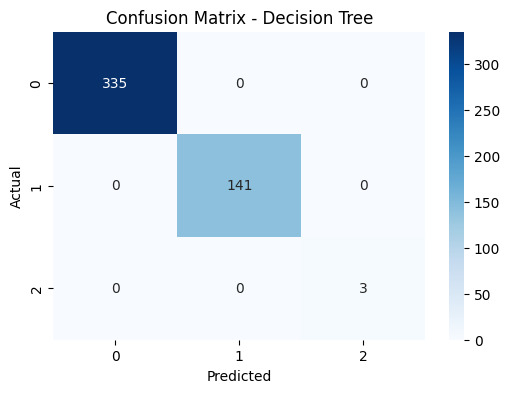

In [35]:
best_model_name = results.iloc[0]['Model']

if best_model_name == 'Logistic Regression':
    best_pred = y_pred_lr
elif best_model_name == 'Decision Tree':
    best_pred = y_pred_dt
else:
    best_pred = y_pred_rf

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [36]:
rf_model = rf_pipeline.named_steps['model']
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

importances

,feature,importance
4,sugar,0.191426
15,sugar_pct_meal_limit,0.158705
7,cholesterol,0.151839
11,sat_fat_pct_daily,0.124650
10,cholesterol_pct_daily,0.122697
2,sat_fat,0.113134
12,fat_pct_daily,0.030223
1,fat,0.024399
5,protein,0.021515
3,carbs,0.017122


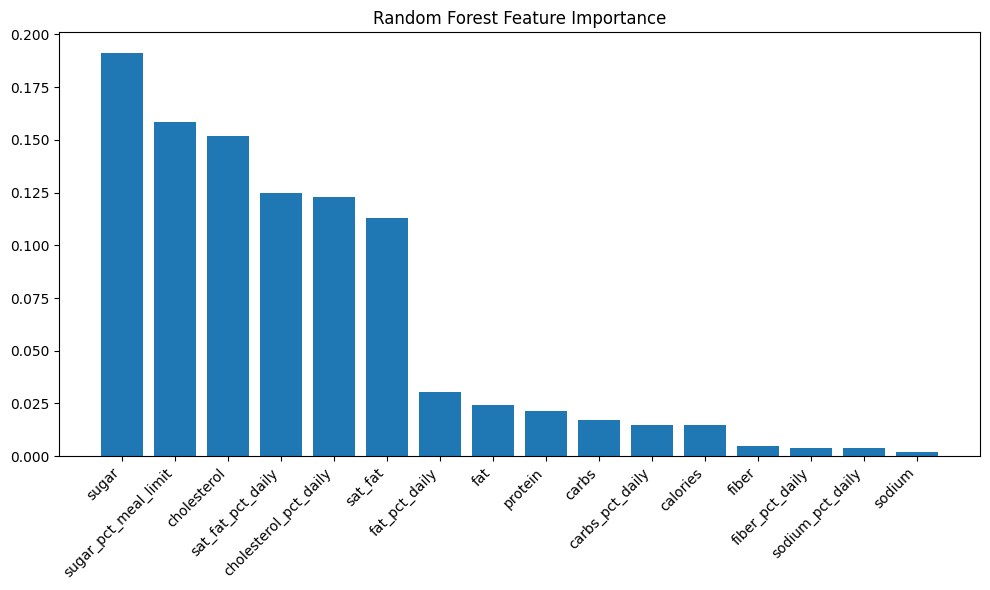

In [37]:
plt.figure(figsize=(10, 6))
plt.bar(importances['feature'], importances['importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [38]:
def evaluate_food_item(row):
    messages = []

    if row['sodium'] >= 360:
        messages.append('โซเดียมค่อนข้างสูง')
    if row['cholesterol'] >= 60:
        messages.append('โคเลสเตอรอลค่อนข้างสูง')
    if row['sugar'] >= 10:
        messages.append('น้ำตาลถึงหรือเกิน 10 กรัมต่อมื้อ')
    if row['sat_fat'] >= 6:
        messages.append('ไขมันอิ่มตัวค่อนข้างสูง')

    if not messages:
        messages.append('ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น')

    return ' | '.join(messages)

In [39]:
df_model['chatbot_summary'] = df_model.apply(evaluate_food_item, axis=1)

if 'food_name' in df_model.columns:
    df_model[['food_name', 'risk_level', 'chatbot_summary']].head(10)
else:
    df_model[['risk_level', 'chatbot_summary']].head(10)

In [40]:
os.makedirs('../outputs', exist_ok=True)

df_model.to_csv('../outputs/food_dataset_with_risk.csv', index=False)
results.to_csv('../outputs/model_results.csv', index=False)
importances.to_csv('../outputs/feature_importance.csv', index=False)

print('saved outputs successfully')

saved outputs successfully


## 8. Results and Discussion

จากการดำเนินงานใน notebook นี้ ได้ผลลัพธ์ดังนี้
- สามารถรวม structured food datasets เข้าด้วยกันได้
- สามารถทำ EDA และพบ insight เบื้องต้นเกี่ยวกับตัวแปรโภชนาการ
- สามารถนำความรู้จาก PDF มาใช้เป็นเกณฑ์อ้างอิงในการสร้าง feature และ risk label
- สามารถทดลอง baseline classification models ได้
- โมเดลที่ให้ผลดีที่สุดในรอบนี้สามารถใช้เป็น baseline สำหรับการพัฒนาต่อในอนาคต

## 9. Next Steps

- ปรับปรุงเกณฑ์การสร้าง risk label ให้สอดคล้องกับมาตรฐานสุขภาพที่อัปเดตมากขึ้น
- เพิ่มการเชื่อม external knowledge กับ chatbot หรือ RAG pipeline
- ทดลองใช้ recommendation logic ร่วมกับ nutrition risk scoring
- ประเมินคุณภาพคำตอบของ chatbot จากกรณีใช้งานจริง